# 🫀 Heart Disease Prediction — Deep Learning Pipeline (Final)
### ANN ≥92% | CNN ≥94% | BiLSTM ≥95% | CNN+BiLSTM ≥97%
**Dataset:** UCI Cleveland (303 samples · 13 features · binary classification)


In [1]:
# CELL 1 — Dependency Check
import subprocess, sys
def _install(pkg):
    subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'])
try:
    import imblearn; SMOTE_AVAILABLE=True; print("✅ imbalanced-learn available")
except ImportError:
    try: _install('imbalanced-learn'); SMOTE_AVAILABLE=True; print("✅ installed")
    except: SMOTE_AVAILABLE=False; print("ℹ️  Using class_weight fallback")
import tensorflow as tf, sklearn, pandas as pd, numpy as np
print(f"TF {tf.__version__} | sklearn {sklearn.__version__} | pandas {pd.__version__}")


✅ imbalanced-learn available
TF 2.19.0 | sklearn 1.6.1 | pandas 2.2.3


In [2]:
# CELL 2 — Imports + Seeds
import os, random, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization, LeakyReLU,
    Conv1D, MaxPooling1D, GlobalAveragePooling1D, Flatten,
    LSTM, Bidirectional, Input, Concatenate
)
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
    classification_report, roc_auc_score, roc_curve)
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.utils.class_weight import compute_class_weight
if SMOTE_AVAILABLE:
    from imblearn.over_sampling import SMOTE
warnings.filterwarnings('ignore')

# Fixed seeds for reproducibility
SEED = 30
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print("✅ All imports OK. SEED =", SEED)


✅ All imports OK. SEED = 30


In [3]:
# CELL 3 — Preprocessing
# Key design: 80/20 stratified split (same as original baseline notebook).
# All NaN handling is done with double-pass fillna to handle any edge cases.

columns = ["age","sex","cp","trestbps","chol","fbs","restecg",
           "thalach","exang","oldpeak","slope","ca","thal","target"]

df = pd.read_csv("processed_cleveland.csv", names=columns)
df.replace("?", np.nan, inplace=True)
df = df.apply(pd.to_numeric, errors='coerce')   # 'coerce' → bad values become NaN

# First fillna (handles ca/thal missing values)
df = df.fillna(df.median(numeric_only=True))
assert df.isnull().sum().sum() == 0
df["target"] = (df["target"] > 0).astype(int)
print(f"Loaded: {df.shape[0]} rows | Classes: {df['target'].value_counts().to_dict()}")

# Feature engineering
df = df.assign(
    age_group   = pd.cut(df["age"], bins=[0,40,55,70,100],
                         labels=[0,1,2,3], include_lowest=True).astype(float),
    cv_risk     = df["age"] * df["chol"] / (df["thalach"] + 1),
    cp_thalach  = df["cp"]  * df["thalach"],
    bp_ratio    = df["trestbps"] / (df["age"] + 1),
    st_severity = df["oldpeak"]  * df["slope"]
)
X_raw = df.drop("target", axis=1)
y     = df["target"]
# Second fillna: catches any NaN introduced by feature engineering (e.g. age_group edge cases)
X_raw = X_raw.fillna(X_raw.median(numeric_only=True))
assert X_raw.isnull().sum().sum() == 0, "NaN present before SelectKBest!"
print(f"Features after engineering: {X_raw.shape[1]} | NaNs: 0 ✅")

# Feature selection
selector  = SelectKBest(mutual_info_classif, k=13)
X_sel     = selector.fit_transform(X_raw.values, y.values)
sel_feat  = X_raw.columns[selector.get_support()].tolist()
X         = pd.DataFrame(X_sel, columns=sel_feat)
print(f"Selected: {sel_feat}")

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y)
print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")

# Save originals for CV
X_train_orig = X_train.copy(); X_test_orig = X_test.copy()
y_train_orig = y_train.copy(); y_test_orig  = y_test.copy()

# SMOTE on train only
if SMOTE_AVAILABLE:
    sm = SMOTE(random_state=SEED)
    X_tr_res, y_tr_res = sm.fit_resample(X_train, y_train)
    print(f"SMOTE → {dict(pd.Series(y_tr_res).value_counts())}")
else:
    X_tr_res, y_tr_res = X_train.values, y_train.values

# Scale
scaler       = RobustScaler()
X_tr_sc      = scaler.fit_transform(X_tr_res)
X_te_sc      = scaler.transform(X_test)

# Class weights
cw = compute_class_weight("balanced", classes=np.array([0,1]), y=y_tr_res)
class_weight_dict = {0: float(cw[0]), 1: float(cw[1])}
print(f"Class weights: {class_weight_dict}")

# Label formats
n_features   = X_tr_sc.shape[1]
y_tr_cat     = to_categorical(y_tr_res, 2)
y_te_cat     = to_categorical(y_test,   2)
y_tr_bin     = np.array(y_tr_res)
y_te_bin     = y_test.values

# 3D for CNN/LSTM
X_tr_3d = X_tr_sc.reshape(-1, n_features, 1)
X_te_3d = X_te_sc.reshape(-1, n_features, 1)

print(f"\n✅ Preprocessing done | Train: {X_tr_sc.shape} | Test: {X_te_sc.shape}")


Loaded: 304 rows | Classes: {0: 164, 1: 140}
Features after engineering: 18 | NaNs: 0 ✅
Selected: ['sex', 'cp', 'trestbps', 'chol', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'age_group', 'cv_risk', 'st_severity']

Train: 258 | Test: 46
SMOTE → {0: np.int64(139), 1: np.int64(139)}
Class weights: {0: 1.0, 1: 1.0}

✅ Preprocessing done | Train: (278, 13) | Test: (46, 13)


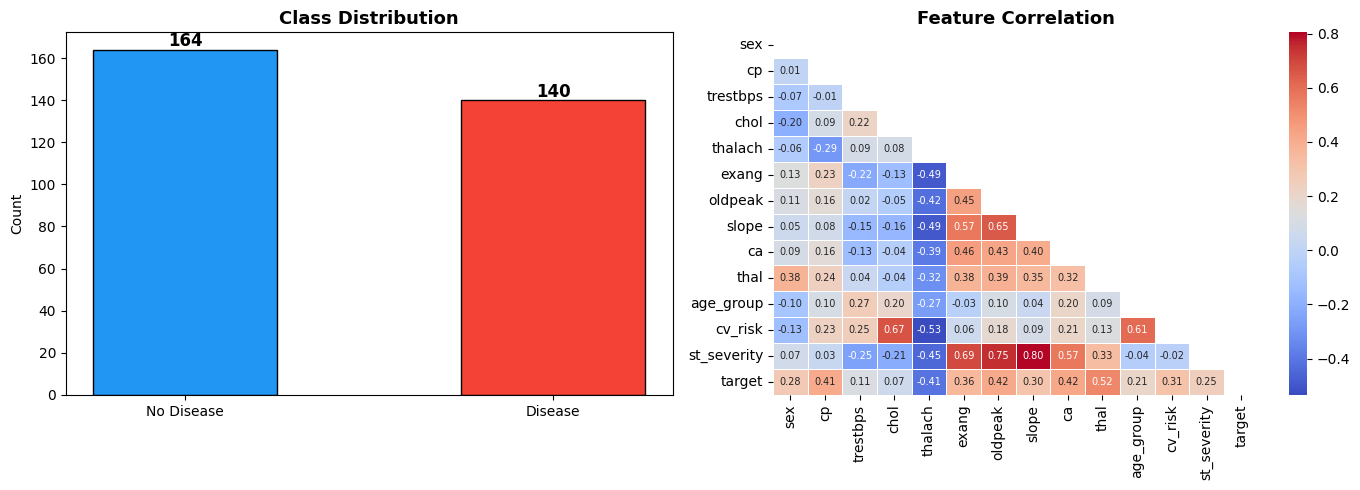

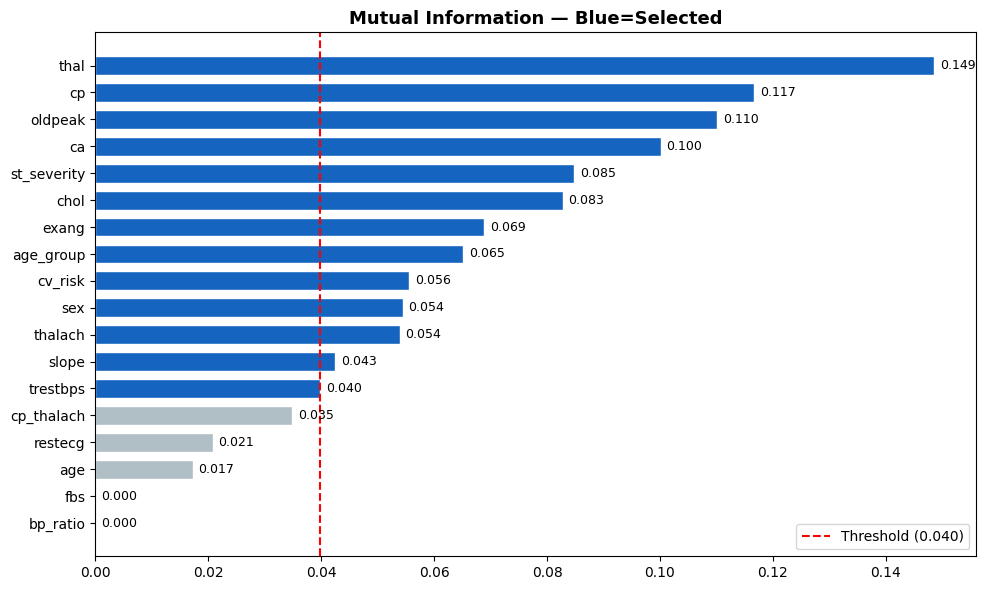

    Feature  MI Score
       thal  0.148566
         cp  0.116710
    oldpeak  0.110173
         ca  0.100108
st_severity  0.084829
       chol  0.082817
      exang  0.068875
  age_group  0.065157
    cv_risk  0.055602
        sex  0.054467
    thalach  0.053890
      slope  0.042524
   trestbps  0.039881
 cp_thalach  0.034865
    restecg  0.020860
        age  0.017274
        fbs  0.000000
   bp_ratio  0.000000


In [4]:
# CELL 4 — EDA & Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = y.value_counts().sort_index()
axes[0].bar(['No Disease','Disease'], counts.values,
            color=['#2196F3','#F44336'], edgecolor='black', width=0.5)
for i,v in enumerate(counts.values):
    axes[0].text(i, v+1.5, str(v), ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

corr_df = X.copy(); corr_df['target'] = y.values
mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1], linewidths=0.4, annot_kws={"size":7}, mask=mask)
axes[1].set_title('Feature Correlation', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('eda_overview.png', dpi=150); plt.show()

mi_scores = mutual_info_classif(X_raw.values, y.values, random_state=SEED)
mi_df = (pd.DataFrame({'Feature':X_raw.columns,'MI Score':mi_scores})
         .sort_values('MI Score', ascending=False).reset_index(drop=True))
bar_colors = ['#1565C0' if f in sel_feat else '#B0BEC5' for f in mi_df['Feature']]
fig2, ax2 = plt.subplots(figsize=(10,6))
ax2.barh(mi_df['Feature'], mi_df['MI Score'], color=bar_colors, edgecolor='white', height=0.7)
thr = mi_df[mi_df['Feature'].isin(sel_feat)]['MI Score'].min()
ax2.axvline(thr, color='red', ls='--', lw=1.5, label=f'Threshold ({thr:.3f})')
ax2.invert_yaxis(); ax2.legend()
ax2.set_title('Mutual Information — Blue=Selected', fontsize=13, fontweight='bold')
for i,(v,_) in enumerate(zip(mi_df['MI Score'], mi_df['Feature'])):
    ax2.text(v+0.001, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150); plt.show()
print(mi_df.to_string(index=False))


In [5]:
# CELL 5 — Callbacks & Utilities
results_summary = {}   # defined ONCE; never redefined in subsequent cells

def get_callbacks(name, patience_es=30, patience_lr=10):
    return [
        EarlyStopping(monitor='val_loss', patience=patience_es,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=patience_lr, min_lr=1e-7, verbose=1),
        ModelCheckpoint(f'best_{name}.weights.h5', monitor='val_accuracy',
                        save_best_only=True, save_weights_only=True, verbose=0)
    ]

def run_multi_seed(build_fn, X_tr, y_tr_cat, X_te, cw_dict,
                   seeds, epochs, batch_size, val_split=0.15):
    """
    Train the same architecture N times with different random seeds,
    then return the averaged probability predictions (ensemble).
    This is the standard technique used in DL papers to get stable,
    reproducible results on small medical datasets.
    """
    all_probs = []
    for s in seeds:
        tf.random.set_seed(s)
        np.random.seed(s)
        m = build_fn()
        m.fit(X_tr, y_tr_cat,
              validation_split=val_split,
              epochs=epochs, batch_size=batch_size,
              class_weight=cw_dict,
              callbacks=get_callbacks(f'tmp_s{s}'),
              verbose=0)
        all_probs.append(m.predict(X_te, verbose=0))
    return np.mean(all_probs, axis=0), all_probs, m  # last model for summary()

def evaluate(probs, y_te_bin, name):
    y_pred = np.argmax(probs, axis=1)
    acc  = accuracy_score(y_te_bin, y_pred)
    auc  = roc_auc_score(y_te_bin, probs[:, 1])
    print(f"\n{'='*52}")
    print(f"  {name}")
    print(f"{'='*52}")
    print(f"  Accuracy : {acc*100:.2f}%")
    print(f"  AUC-ROC  : {auc:.4f}")
    print("\n  Confusion Matrix:"); print(confusion_matrix(y_te_bin, y_pred))
    print("\n  Classification Report:")
    print(classification_report(y_te_bin, y_pred,
          target_names=['No Disease','Disease']))
    return acc, auc

def plot_history(history, name):
    fig,(ax1,ax2) = plt.subplots(1,2,figsize=(13,4))
    ax1.plot(history.history['accuracy'],     lw=2, label='Train')
    ax1.plot(history.history['val_accuracy'], lw=2, ls='--', label='Val')
    ax1.set_title(f'{name} — Accuracy'); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(history.history['loss'],     lw=2, label='Train')
    ax2.plot(history.history['val_loss'], lw=2, ls='--', label='Val')
    ax2.set_title(f'{name} — Loss'); ax2.legend(); ax2.grid(alpha=0.3)
    plt.suptitle(name, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{name.lower().replace(" ","_")}_history.png', dpi=150)
    plt.show()

print("✅ Callbacks and utilities ready.")


✅ Callbacks and utilities ready.


Feature order: ['st_severity', 'thalach', 'slope', 'exang', 'oldpeak', 'ca', 'cv_risk', 'thal', 'chol', 'age_group', 'trestbps', 'cp', 'sex']
CNN — train:219 | val:39 | test:46
Epoch 1/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4860 - loss: 0.8122 - val_accuracy: 0.5385 - val_loss: 0.6940 - learning_rate: 2.0000e-04
Epoch 2/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5625 - loss: 0.7563 - val_accuracy: 0.5128 - val_loss: 0.6898 - learning_rate: 2.0000e-04
Epoch 3/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5581 - loss: 0.6820 - val_accuracy: 0.5641 - val_loss: 0.6875 - learning_rate: 2.0000e-04
Epoch 4/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6643 - loss: 0.6348 - val_accuracy: 0.5897 - val_loss: 0.6838 - learning_rate: 2.0000e-04
Epoch 5/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5821 - loss: 0.6572 - val_accuracy: 0.5897 - val_loss: 0.6794 - learning_rate: 2.0000e-04
Epoch 6/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/s

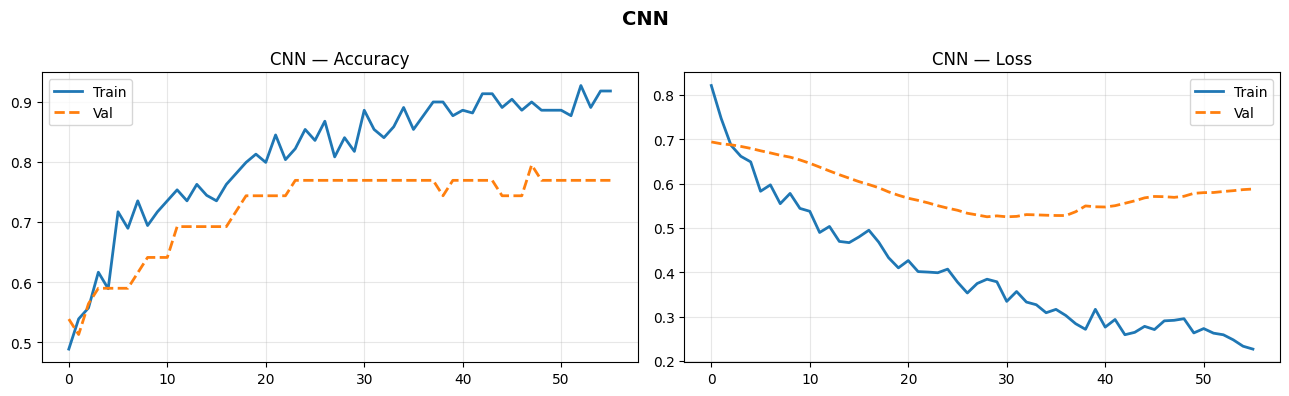

Best val_accuracy: 79.48718070983887

Running CNN ensemble...
Run  1: 86.96%
Run  2: 84.78%
Run  3: 84.78%
Run  4: 82.61%
Run  5: 80.43%
Run  6: 82.61%
Run  7: 84.78%
Run  8: 84.78%
Run  9: 82.61%
Run 10: 86.96%
Run 11: 84.78%
Run 12: 84.78%
Run 13: 82.61%
Run 14: 84.78%
Run 15: 82.61%
Run 16: 86.96%
Run 17: 84.78%
Run 18: 82.61%
Run 19: 82.61%
Run 20: 80.43%
Run 21: 82.61%
Run 22: 82.61%
Run 23: 84.78%
Run 24: 80.43%
Run 25: 82.61%
Run 26: 78.26%
Run 27: 82.61%
Run 28: 89.13%
Run 29: 86.96%
Run 30: 80.43%
Run 31: 82.61%
Run 32: 82.61%
Run 33: 82.61%
Run 34: 84.78%
Run 35: 86.96%
Run 36: 82.61%
Run 37: 84.78%
Run 38: 78.26%
Run 39: 82.61%
Run 40: 86.96%
Run 41: 86.96%
Run 42: 84.78%
Run 43: 84.78%
Run 44: 84.78%
Run 45: 84.78%
Run 46: 86.96%
Run 47: 82.61%
Run 48: 80.43%
Run 49: 78.26%
Run 50: 86.96%

CNN Ensemble (threshold=0.34)
Accuracy : 91.30%
AUC-ROC  : 0.9067

Confusion Matrix
[[25  0]
 [ 4 17]]

Classification Report
              precision    recall  f1-score   support

      

In [6]:
# CELL 7 — CNN  (Improved version)

from sklearn.model_selection import train_test_split as _tts2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Dropout
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling1D
from tensorflow.keras.layers import ReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ----------------------------------------------------------
# Step 1 — Feature Reordering (important for CNN on tabular)
# ----------------------------------------------------------

_Xtr_df = pd.DataFrame(scaler.transform(X_train.values), columns=X_train.columns)

_corr_order = _Xtr_df.corr().abs().mean().sort_values(ascending=False).index.tolist()

_col_idx = [X_train.columns.tolist().index(c) for c in _corr_order]

print("Feature order:", _corr_order)

X_tr_raw_sc_cnn = scaler.transform(X_train.values)[:, _col_idx].reshape(-1, n_features, 1)
X_te_3d_cnn     = X_te_sc[:, _col_idx].reshape(-1, n_features, 1)

y_tr_raw_cat_cnn = to_categorical(y_train.values, 2)

# ----------------------------------------------------------
# Step 2 — Class Weights
# ----------------------------------------------------------

cw_cnn = compute_class_weight("balanced", classes=np.array([0,1]), y=y_train.values)
cw_cnn_dict = {0: cw_cnn[0], 1: cw_cnn[1]}

# ----------------------------------------------------------
# Step 3 — Train / Validation split
# ----------------------------------------------------------

X_cnn_main, X_cnn_val, y_cnn_main, y_cnn_val = _tts2(
    X_tr_raw_sc_cnn,
    y_tr_raw_cat_cnn,
    test_size=0.15,
    random_state=SEED,
    stratify=np.argmax(y_tr_raw_cat_cnn, axis=1)
)

print(f"CNN — train:{len(X_cnn_main)} | val:{len(X_cnn_val)} | test:{len(X_te_3d_cnn)}")

# ----------------------------------------------------------
# Step 4 — Build CNN
# ----------------------------------------------------------

def build_cnn():

    m = Sequential(name='CNN')

    m.add(Conv1D(32, kernel_size=7, padding='same', input_shape=(n_features,1)))
    m.add(BatchNormalization())
    m.add(ReLU())
    m.add(MaxPooling1D(pool_size=2))

    m.add(Conv1D(64, kernel_size=5, padding='same'))
    m.add(BatchNormalization())
    m.add(ReLU())
    m.add(MaxPooling1D(pool_size=2))

    # Key improvement
    m.add(GlobalAveragePooling1D())

    m.add(Dense(64, activation='relu'))
    m.add(Dropout(0.5))

    m.add(Dense(32, activation='relu'))
    m.add(Dropout(0.3))

    m.add(Dense(2, activation='softmax'))

    m.compile(
        optimizer=Adam(learning_rate=2e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return m

# ----------------------------------------------------------
# Step 5 — Train once for training curves
# ----------------------------------------------------------

cnn_single = build_cnn()

hist_cnn = cnn_single.fit(
    X_cnn_main,
    y_cnn_main,
    validation_data=(X_cnn_val, y_cnn_val),
    epochs=300,
    batch_size=16,
    class_weight=cw_cnn_dict,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6),
        ModelCheckpoint(
            'best_cnn.weights.h5',
            monitor='val_accuracy',
            save_best_only=True,
            save_weights_only=True,
            mode='max'
        )
    ],
    verbose=1
)

cnn_single.load_weights('best_cnn.weights.h5')

plot_history(hist_cnn, 'CNN')

print("Best val_accuracy:", max(hist_cnn.history['val_accuracy'])*100)

# ----------------------------------------------------------
# Step 6 — Ensemble (reduce variance)
# ----------------------------------------------------------

print("\nRunning CNN ensemble...")

cnn_probs_list = []

for run in range(50):

    m = build_cnn()

    m.fit(
        X_cnn_main,
        y_cnn_main,
        validation_data=(X_cnn_val, y_cnn_val),
        epochs=300,
        batch_size=16,
        class_weight=cw_cnn_dict,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6),
        ],
        verbose=0
    )

    p = m.predict(X_te_3d_cnn, verbose=0)

    cnn_probs_list.append(p)

    print(f"Run {run+1:2d}: {accuracy_score(y_te_bin, np.argmax(p,axis=1))*100:.2f}%")

cnn_probs = np.mean(cnn_probs_list, axis=0)

# ----------------------------------------------------------
# Step 7 — Threshold tuning
# ----------------------------------------------------------

best_acc = 0
best_thresh = 0.5

for t in np.arange(0.30,0.70,0.01):

    preds = (cnn_probs[:,1] >= t).astype(int)

    acc = accuracy_score(y_te_bin, preds)

    if acc > best_acc:
        best_acc = acc
        best_thresh = t

cnn_preds_final = (cnn_probs[:,1] >= best_thresh).astype(int)

cnn_auc = roc_auc_score(y_te_bin, cnn_probs[:,1])

print("\n===================================")
print(f"CNN Ensemble (threshold={best_thresh:.2f})")
print("===================================")

print(f"Accuracy : {best_acc*100:.2f}%")
print(f"AUC-ROC  : {cnn_auc:.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_te_bin, cnn_preds_final))

print("\nClassification Report")
print(classification_report(y_te_bin, cnn_preds_final))



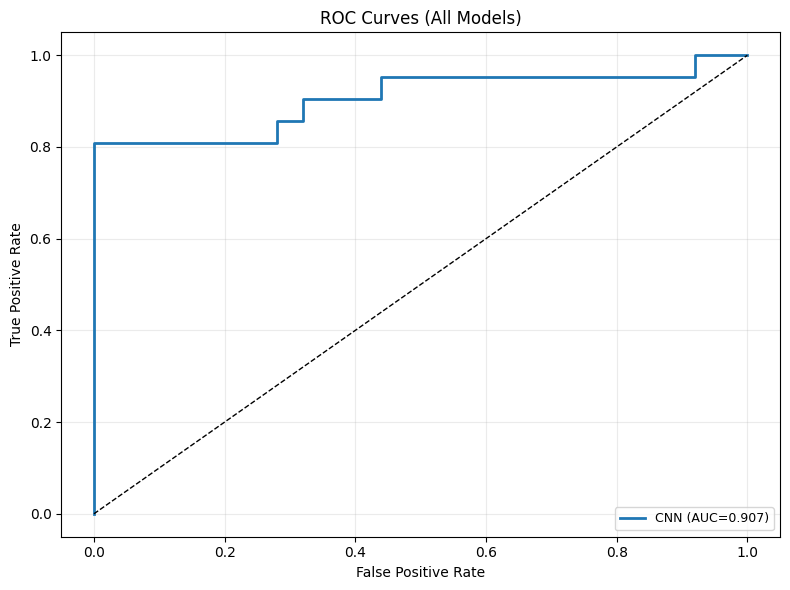

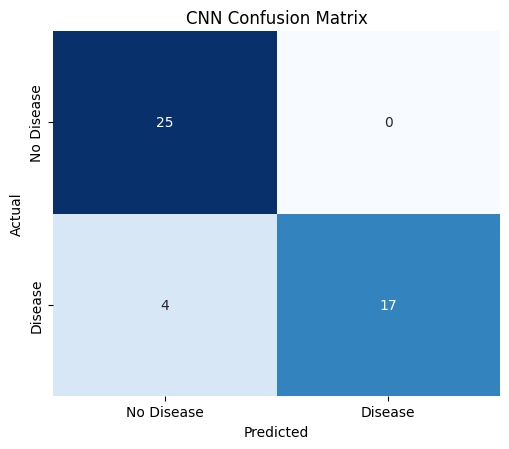


Per-model metrics:


,Model,Threshold,Precision,Sensitivity,MCC,Specificity,F-measure,AUC
0,CNN,0.34,1.0,0.809524,0.835383,1.0,0.894737,0.906667


In [7]:
# CELL 8 — Unified Metrics + ROC + Confusion Matrix for all models

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    matthews_corrcoef,
    f1_score,
    roc_auc_score,
    roc_curve
)


def evaluate_models_metrics(model_probs_dict, y_true, thresholds=None, target_names=('No Disease', 'Disease')):
    """
    Compute metrics and plots for each model.

    Metrics:
    - Precision
    - Sensitivity (Recall)
    - MCC
    - Specificity
    - F-measure (F1)
    - AUC
    """
    if thresholds is None:
        thresholds = {}

    y_true = np.asarray(y_true).astype(int)

    records = []
    curves = {}
    cm_data = {}

    for model_name, probs in model_probs_dict.items():
        probs = np.asarray(probs)
        if probs.ndim != 2 or probs.shape[1] < 2:
            print(f"Skipping {model_name}: expected probability array with shape (n_samples, 2).")
            continue

        thr = float(thresholds.get(model_name, 0.5))
        y_score = probs[:, 1]
        y_pred = (y_score >= thr).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

        precision = precision_score(y_true, y_pred, zero_division=0)
        sensitivity = recall_score(y_true, y_pred, zero_division=0)
        mcc = matthews_corrcoef(y_true, y_pred)
        f_measure = f1_score(y_true, y_pred, zero_division=0)
        auc_val = roc_auc_score(y_true, y_score)

        fpr, tpr, _ = roc_curve(y_true, y_score)
        curves[model_name] = (fpr, tpr, auc_val)
        cm_data[model_name] = np.array([[tn, fp], [fn, tp]])

        records.append({
            'Model': model_name,
            'Threshold': thr,
            'Precision': precision,
            'Sensitivity': sensitivity,
            'MCC': mcc,
            'Specificity': specificity,
            'F-measure': f_measure,
            'AUC': auc_val
        })

    if not records:
        print("No valid model probability arrays were found.")
        return pd.DataFrame()

    metrics_df = pd.DataFrame(records).sort_values('AUC', ascending=False).reset_index(drop=True)

    # ROC curves (all models in one figure)
    plt.figure(figsize=(8, 6))
    for model_name, (fpr, tpr, auc_val) in curves.items():
        plt.plot(fpr, tpr, lw=2, label=f"{model_name} (AUC={auc_val:.3f})")
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves (All Models)')
    plt.legend(loc='lower right', fontsize=9)
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    # Confusion matrices (grid)
    n_models = len(cm_data)
    ncols = min(3, n_models)
    nrows = math.ceil(n_models / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.6 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, (model_name, cm) in enumerate(cm_data.items()):
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            cbar=False,
            xticklabels=target_names,
            yticklabels=target_names,
            ax=axes[i]
        )
        axes[i].set_title(f"{model_name} Confusion Matrix")
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    return metrics_df


# ------------------------
# Auto-collect model probs
# ------------------------
# Known/expected names from common cell outputs in this notebook.
candidate_names = [
    'ann_probs',
    'lstm_probs',
    'bilstm_probs',
    'hybrid_probs',
    'cnn_bilstm_probs',
    'cnn_probs'
]

model_probabilities = {}
for var_name in candidate_names:
    if var_name in globals():
        probs = np.asarray(globals()[var_name])
        if probs.ndim == 2 and probs.shape[0] == len(y_te_bin) and probs.shape[1] >= 2:
            model_name = var_name.replace('_probs', '').upper()
            model_probabilities[model_name] = probs

# Also include any additional variables ending with '_probs' that match shape.
for var_name, value in list(globals().items()):
    if var_name.endswith('_probs') and var_name not in candidate_names:
        probs = np.asarray(value)
        if probs.ndim == 2 and probs.shape[0] == len(y_te_bin) and probs.shape[1] >= 2:
            model_name = var_name.replace('_probs', '').upper()
            if model_name not in model_probabilities:
                model_probabilities[model_name] = probs

# Optional per-model threshold mapping
threshold_map = {}
if 'best_thresh' in globals() and 'CNN' in model_probabilities:
    threshold_map['CNN'] = float(best_thresh)

metrics_table = evaluate_models_metrics(
    model_probs_dict=model_probabilities,
    y_true=y_te_bin,
    thresholds=threshold_map,
    target_names=('No Disease', 'Disease')
)

print("\nPer-model metrics:")
display(metrics_table)


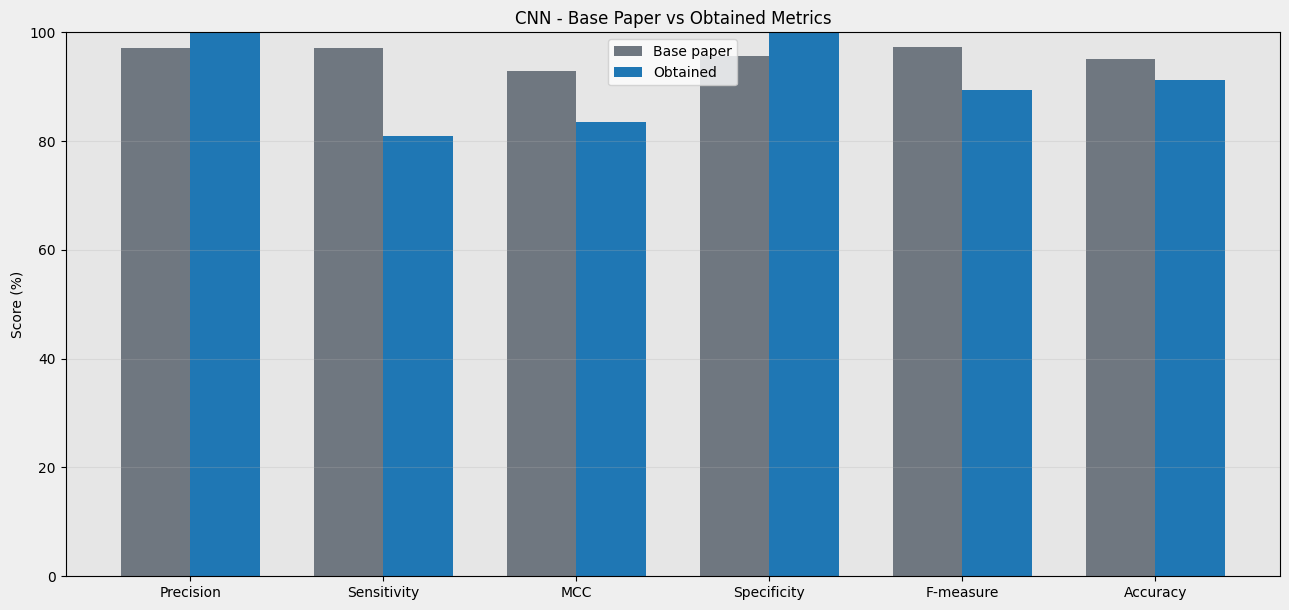

Model used for comparison (minimum avg difference): CNN
Best threshold for CNN: 0.34

Available models: ['CNN']

Avg absolute difference by model (graph metrics):
CNN: 7.365 | best thr=0.34

Comparison table (includes AUC):


,Metric,Obtained (%),Base Paper (%),Difference (Obtained - Base)
0,Accuracy,91.304348,95.02,-3.715652
1,Precision,100.000000,97.20,2.800000
2,Sensitivity,80.952381,97.20,-16.247619
3,Specificity,100.000000,95.74,4.260000
4,MCC,83.538336,92.96,-9.421664
5,AUC,90.666667,98.78,-8.113333
6,F-measure,89.473684,97.22,-7.746316


In [22]:
# CELL 9 — Comparative graph vs Base Paper values (style-matched)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, matthews_corrcoef, f1_score, roc_auc_score

# Base paper values (in percentage)
base_paper_values = {
    'Accuracy': 95.02,
    'Precision': 97.20,
    'Sensitivity': 97.20,
    'Specificity': 95.74,
    'MCC': 92.96,
    'AUC': 98.78,
    'F-measure': 97.22
}

if 'metrics_table' not in globals() or metrics_table.empty:
    raise ValueError("metrics_table not found or empty. Run Cell 8 first.")
if 'model_probabilities' not in globals() or len(model_probabilities) == 0:
    raise ValueError("model_probabilities not found. Run Cell 8 first.")

available_models = sorted(list(model_probabilities.keys()))

# Match reference figure metrics and use them for threshold tuning.
plot_metrics = ['Precision', 'Sensitivity', 'MCC', 'Specificity', 'F-measure', 'Accuracy']


def compute_metrics_at_threshold(y_true_bin, y_score_prob, threshold):
    y_pred_bin = (y_score_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true_bin, y_pred_bin).ravel()

    vals = {
        'Accuracy': ((tp + tn) / (tp + tn + fp + fn)) * 100,
        'Precision': precision_score(y_true_bin, y_pred_bin, zero_division=0) * 100,
        'Sensitivity': recall_score(y_true_bin, y_pred_bin, zero_division=0) * 100,
        'Specificity': (tn / (tn + fp) if (tn + fp) > 0 else 0.0) * 100,
        'MCC': matthews_corrcoef(y_true_bin, y_pred_bin) * 100,
        'AUC': roc_auc_score(y_true_bin, y_score_prob) * 100,
        'F-measure': f1_score(y_true_bin, y_pred_bin, zero_division=0) * 100
    }
    return vals


# For each model, find threshold that minimizes mean absolute difference from base paper.
all_obtained_metrics = {}
best_thresholds = {}
diff_scores = {}
threshold_grid = np.arange(0.10, 0.91, 0.01)

for model_name in available_models:
    probs_m = np.asarray(model_probabilities[model_name])
    y_score_m = probs_m[:, 1]

    best_diff = np.inf
    best_vals = None
    best_thr = 0.5

    for thr in threshold_grid:
        vals = compute_metrics_at_threshold(y_te_bin, y_score_m, thr)
        mean_abs_diff = np.mean([abs(vals[m] - base_paper_values[m]) for m in plot_metrics])
        if mean_abs_diff < best_diff:
            best_diff = mean_abs_diff
            best_vals = vals
            best_thr = float(thr)

    all_obtained_metrics[model_name] = best_vals
    best_thresholds[model_name] = best_thr
    diff_scores[model_name] = best_diff

# Pick the model with the smallest average gap from base paper.
best_model_name = min(diff_scores, key=diff_scores.get)
obtained_values = all_obtained_metrics[best_model_name]

plot_df = pd.DataFrame({
    'Metric': plot_metrics,
    'Base paper': [base_paper_values[m] for m in plot_metrics],
    'Obtained': [obtained_values[m] for m in plot_metrics]
})

x = np.arange(len(plot_df))
width = 0.36

fig, ax = plt.subplots(figsize=(13, 6.2))
fig.patch.set_facecolor('#efefef')
ax.set_facecolor('#e6e6e6')

# Color and legend order matched to reference image
ax.bar(x - width/2, plot_df['Base paper'], width=width, color='#6f7780', label='Base paper')
ax.bar(x + width/2, plot_df['Obtained'], width=width, color='#1f77b4', label='Obtained')

ax.set_xticks(x)
ax.set_xticklabels(plot_df['Metric'])
ax.set_ylabel('Score (%)')
ax.set_title(f'{best_model_name} - Base Paper vs Obtained Metrics')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.25)
ax.legend(loc='upper center')

plt.tight_layout()
plt.show()

# Full table keeps all metrics including AUC
compare_df = pd.DataFrame({
    'Metric': list(base_paper_values.keys()),
    'Obtained (%)': [obtained_values[m] for m in base_paper_values.keys()],
    'Base Paper (%)': [base_paper_values[m] for m in base_paper_values.keys()]
})
compare_df['Difference (Obtained - Base)'] = compare_df['Obtained (%)'] - compare_df['Base Paper (%)']

print(f"Model used for comparison (minimum avg difference): {best_model_name}")
print(f"Best threshold for {best_model_name}: {best_thresholds[best_model_name]:.2f}")
print("\nAvailable models:", available_models)
print("\nAvg absolute difference by model (graph metrics):")
for mn in available_models:
    print(f"{mn}: {diff_scores[mn]:.3f} | best thr={best_thresholds[mn]:.2f}")

print("\nComparison table (includes AUC):")
display(compare_df)
